In [65]:
import jax
import jax.numpy as jnp

def lossless_contact(non_dim_eta):
    return jnp.abs(non_dim_eta)**2

def loss_contact(scattering_length, eta):
    a_s = jnp.asarray(scattering_length, dtype=jnp.complex64) 
    return jnp.imag(1/a_s) * jnp.abs(eta)**2
    
def diff(grid):
    return grid[1:]-grid[:-1]

def cumulative_trapez_int(integrand, dx):
    interval_integrals = 0.5 * dx * (integrand[:-1] + integrand[1:])
    initial_value = jnp.zeros((1,), dtype=interval_integrals.dtype)
    return jnp.concatenate((initial_value, jnp.cumsum(interval_integrals)))

def trapez_int(integrand, dx):
    return cumulative_trapez_int(integrand, dx)[-1]
    
def mol_density(scattering_length, eta, time_interval=1.0):
    # for inelastic models with complex scattering lengths.
    a_s = jnp.asarray(scattering_length, dtype=jnp.complex64) 
    eta = jnp.asarray(eta, dtype=jnp.complex64) 
    N = a_s.shape[0] - 1
    dt = time_interval / N

    prefix = (1 / (2 * jnp.pi))
    contact = loss_contact(a_s, eta)
    mol_den = prefix * cumulative_trapez_int(contact, dt)
    return mol_den 

def energy_density(scattering_length, eta):
    # for elastic models with real scattering lengths. 
    a_s = jnp.asarray(scattering_length, dtype=jnp.float32) 
    eta = jnp.asarray(eta, dtype=jnp.complex64) 
    
    prefix = 1/(8*jnp.pi)

    integr = lossless_contact(eta) / (a_s**2)
    ener_den = prefix * cumulative_trapez_int(integr, diff(a_s))

    return ener_den
    
    
    
    
    

    


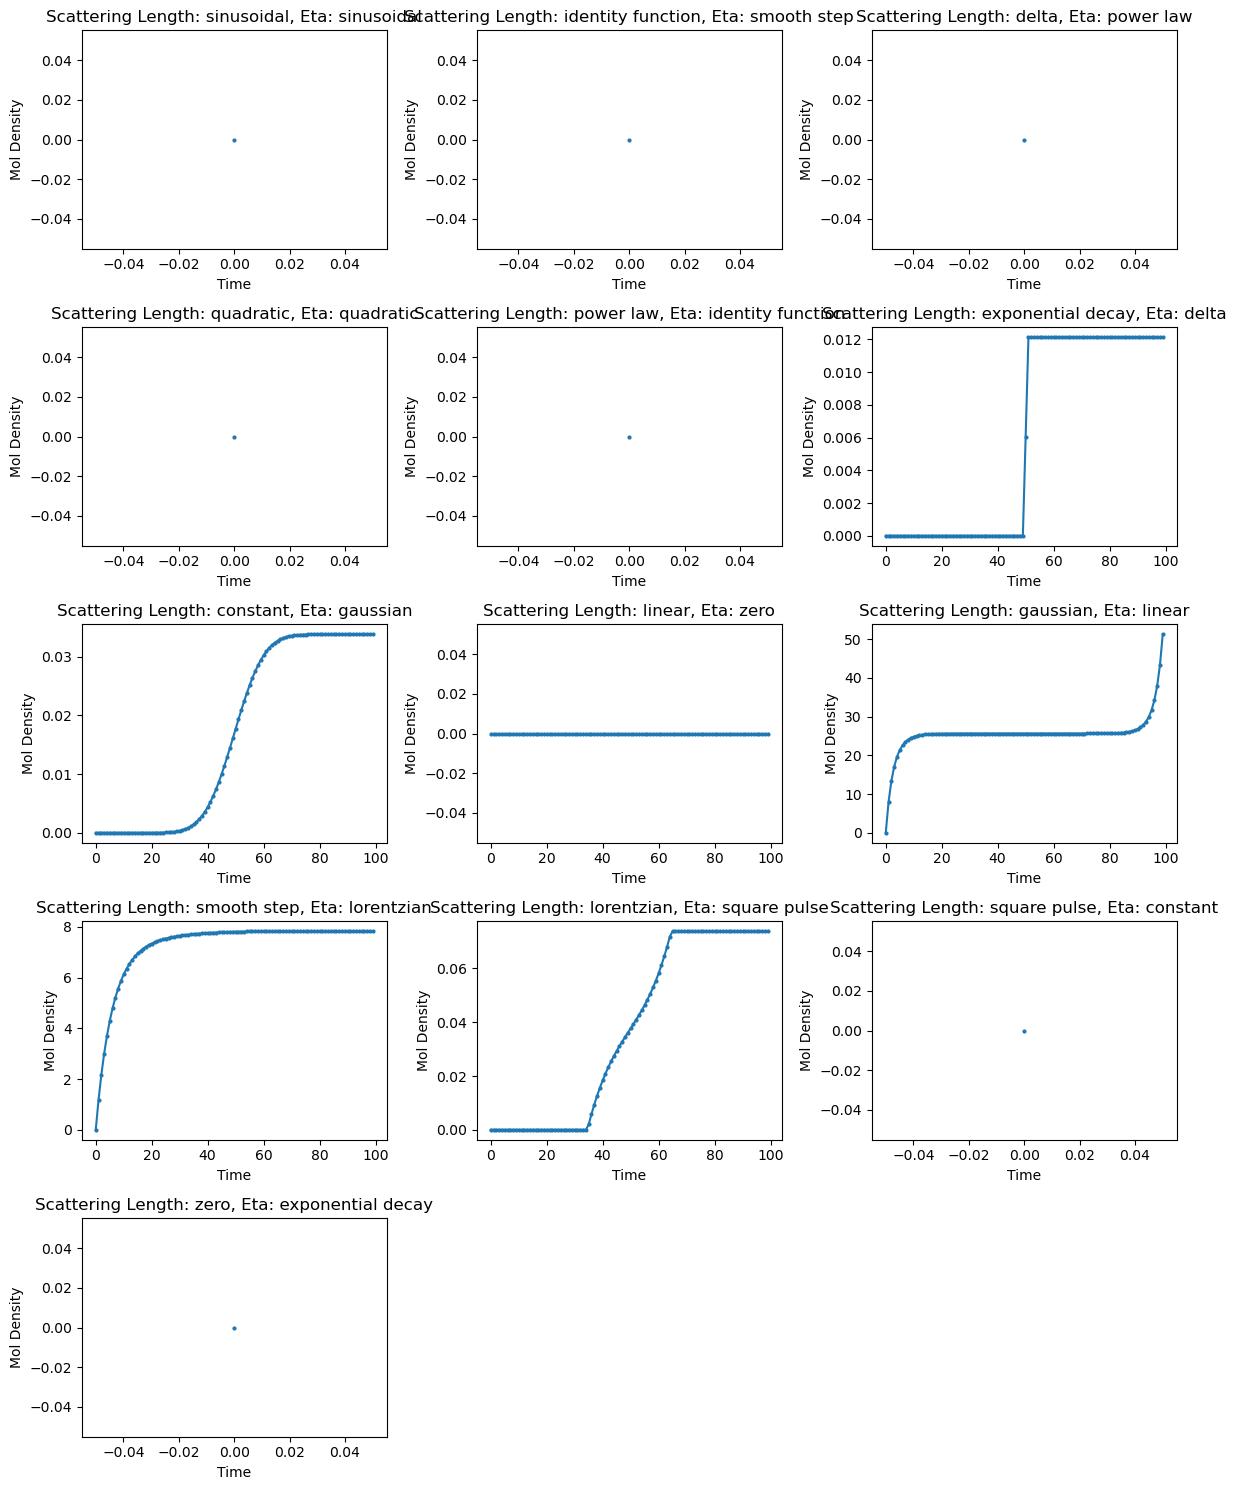

In [66]:
%run ./test.ipynb
import math
import numpy as np
import matplotlib.pyplot as plt

function_under_test = mol_density

test_variable_names = ["Scattering Length", "Eta"]
array_length = 100
random_seed = 0
curve_types_to_test = None 
complex_values = True
x_axis_name = "Time"
y_axis_name = "Mol Density"
plot_columns = 3
fixed_args_before_test_arrays = () 
fixed_args_after_test_arrays = () 


dataset = make_test_dataset(
    test_variable_names,
    length=array_length,
    seed=random_seed,
    curve_types=curve_types_to_test,
    complex_values=complex_values,
)
test_combinations = list(zip(*(dataset[name] for name in dataset.names)))

results = []
for curves in test_combinations:
    test_arrays = [curve.values for curve in curves]
    output_array = function_under_test(
        *fixed_args_before_test_arrays,
        *test_arrays,
        *fixed_args_after_test_arrays,
    )
    results.append((curves, output_array))

if not results:
    raise ValueError("No test combinations were generated.")

ncols = min(max(1, plot_columns), len(results))
nrows = math.ceil(len(results) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
axes = axes.ravel()

for ax, (curves, y_values) in zip(axes, results):
    y_values = np.asarray(y_values)
    time = range(len(y_values))
    title = ", ".join(f"{curve.name}: {curve.curve_type}" for curve in curves)
    if np.iscomplexobj(y_values):
        y_values = np.abs(y_values)
    ax.plot(time, y_values, marker="o", markersize=2, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(x_axis_name)
    ax.set_ylabel(y_axis_name)

for ax in axes[len(results):]:
    ax.set_visible(False)

fig.tight_layout()

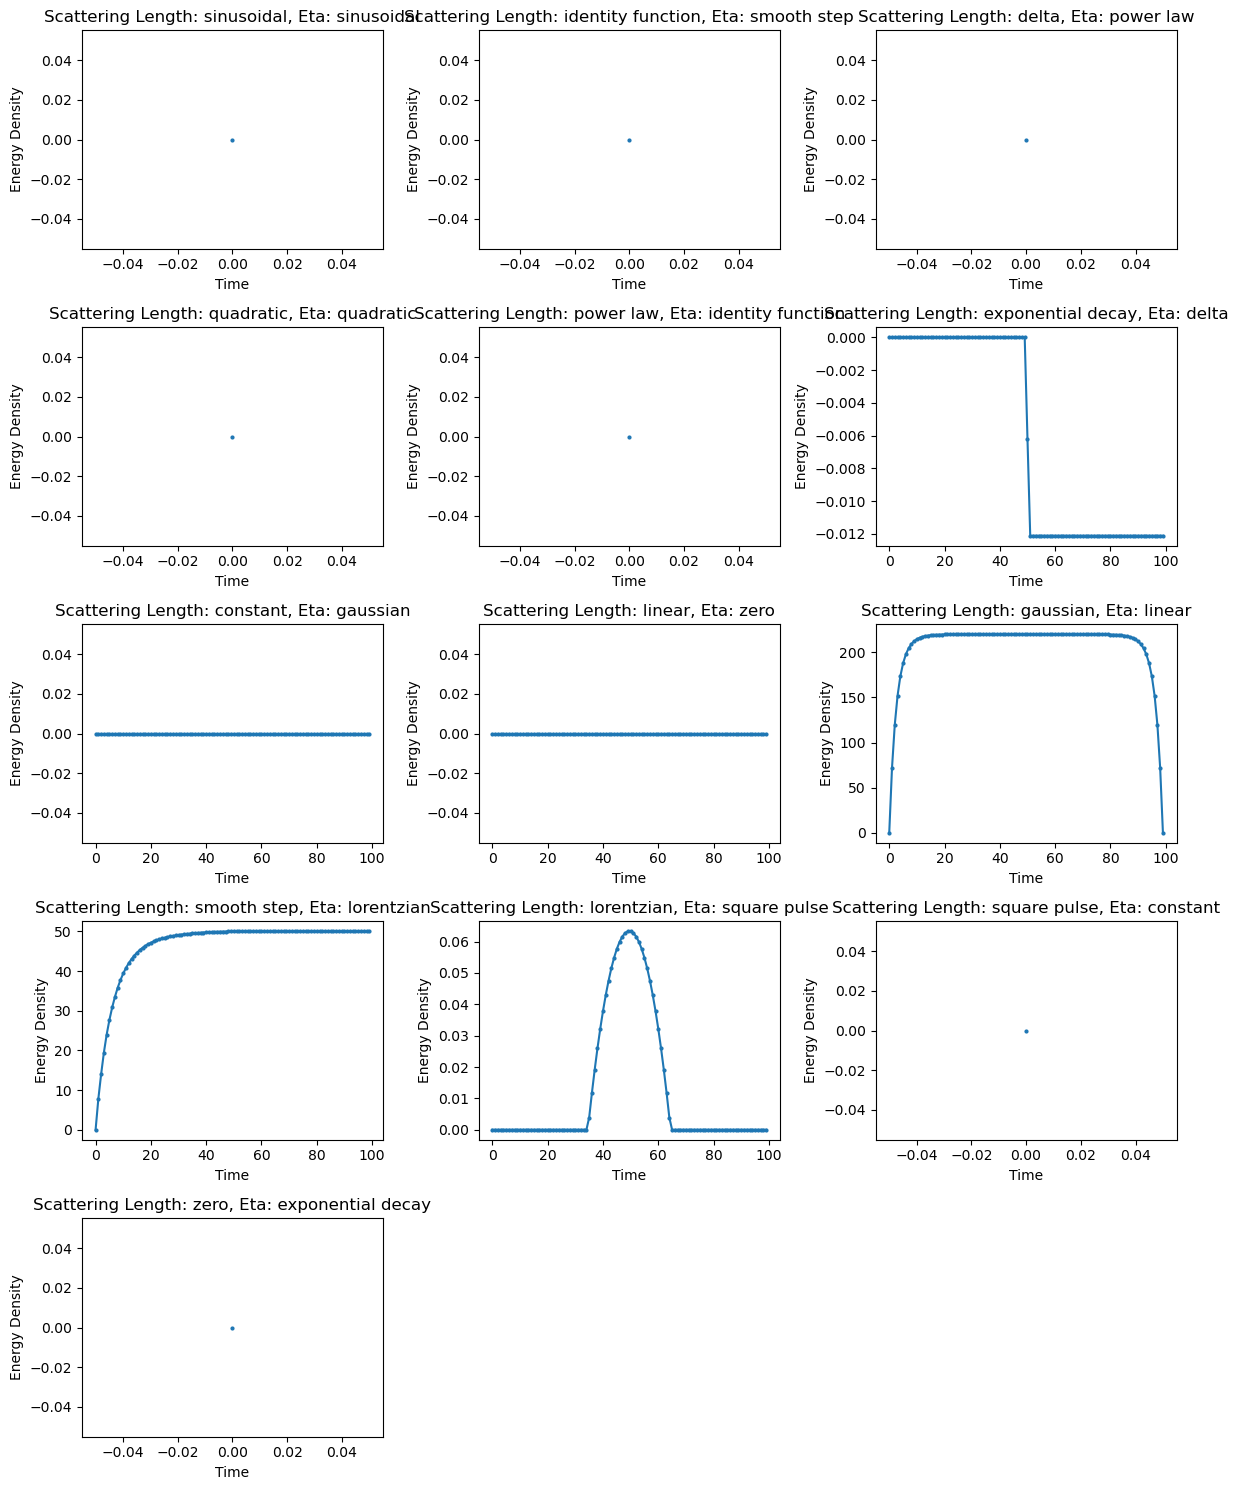

In [68]:
%run ./test.ipynb
import math
import numpy as np
import matplotlib.pyplot as plt

function_under_test = energy_density 

test_variable_names = ["Scattering Length", "Eta"]
array_length = 100
random_seed = 0
curve_types_to_test = None 
complex_values = False 
x_axis_name = "Time"
y_axis_name = "Energy Density"
plot_columns = 3
fixed_args_before_test_arrays = () 
fixed_args_after_test_arrays = () 


dataset = make_test_dataset(
    test_variable_names,
    length=array_length,
    seed=random_seed,
    curve_types=curve_types_to_test,
    complex_values=complex_values,
)
test_combinations = list(zip(*(dataset[name] for name in dataset.names)))

results = []
for curves in test_combinations:
    test_arrays = [curve.values for curve in curves]
    output_array = function_under_test(
        *fixed_args_before_test_arrays,
        *test_arrays,
        *fixed_args_after_test_arrays,
    )
    results.append((curves, output_array))
if not results:
    raise ValueError("No test combinations were generated.")

ncols = min(max(1, plot_columns), len(results))
nrows = math.ceil(len(results) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
axes = axes.ravel()

for ax, (curves, y_values) in zip(axes, results):
    y_values = np.asarray(y_values)
    time = range(len(y_values))
    title = ", ".join(f"{curve.name}: {curve.curve_type}" for curve in curves)
    if np.iscomplexobj(y_values):
        y_values = np.abs(y_values)
    ax.plot(time, y_values, marker="o", markersize=2, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(x_axis_name)
    ax.set_ylabel(y_axis_name)

for ax in axes[len(results):]:
    ax.set_visible(False)

fig.tight_layout()